You will be working on this project with Google Colaboratory.

After going to that link, create a copy of the notebook either in your own account or locally. Once you complete the project and it passes the test (included at that link), submit your project link below. If you are submitting a Google Colaboratory link, make sure to turn on link sharing for "anyone with the link."

We are still developing the interactive instructional content for the machine learning curriculum. For now, you can go through the video challenges in this certification. You may also have to seek out additional learning resources, similar to what you would do when working on a real-world project.

In this challenge, you will create a book recommendation algorithm using K-Nearest Neighbors.

In this project, you will use the Book-Crossings dataset, which contains 1.1 million ratings (scale of 1-10) of 270,000 books by 90,000 users. The dataset is already imported in the notebook, so no additional download is required.

Use NearestNeighbors from sklearn.neighbors to develop a model that shows books that are similar to a given book. The Nearest Neighbors algorithm measures the distance to determine the “closeness” of instances.

Create a function named get_recommends that takes a book title (from the dataset) as an argument and returns a list of 5 similar books with their distances from the book argument.

This code:

get_recommends("The Queen of the Damned (Vampire Chronicles (Paperback))")
should return:

[
  'The Queen of the Damned (Vampire Chronicles (Paperback))',
  [
    ['Catch 22', 0.793983519077301], 
    ['The Witching Hour (Lives of the Mayfair Witches)', 0.7448656558990479], 
    ['Interview with the Vampire', 0.7345068454742432],
    ['The Tale of the Body Thief (Vampire Chronicles (Paperback))', 0.5376338362693787],
    ['The Vampire Lestat (Vampire Chronicles, Book II)', 0.5178412199020386]
  ]
]
Notice that the data returned from get_recommends() is a list. The first element in the list is the book title passed into the function. The second element in the list is a list of five more lists. Each of the five lists contains a recommended book and the distance from the recommended book to the book passed into the function.

If you graph the dataset (optional), you will notice that most books are not rated frequently. To ensure statistical significance, remove from the dataset users with less than 200 ratings and books with less than 100 ratings.

The first three cells import libraries you may need and the data to use. The final cell is for testing. Write all your code in between those cells.

In [3]:
# import libraries (you may add additional imports but you may not have to)

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [4]:
# get data files
import os
import zipfile
from urllib.request import urlretrieve

ZIP_PATH = "book-crossings.zip"
URL = "https://cdn.freecodecamp.org/project-data/books/book-crossings.zip"

if not (os.path.isfile("BX-Books.csv") and os.path.isfile("BX-Book-Ratings.csv")):
    if not os.path.isfile(ZIP_PATH):
        print("Downloading", ZIP_PATH)
        urlretrieve(URL, ZIP_PATH)
    print("Extracting", ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(".")

books_filename = "BX-Books.csv"
ratings_filename = "BX-Book-Ratings.csv"


In [5]:
# import csv data into dataframes
df_books = pd.read_csv(
    books_filename,
    encoding = "ISO-8859-1",
    sep=";",
    header=0,
    names=['isbn', 'title', 'author'],
    usecols=['isbn', 'title', 'author'],
    dtype={'isbn': 'str', 'title': 'str', 'author': 'str'})

df_ratings = pd.read_csv(
    ratings_filename,
    encoding = "ISO-8859-1",
    sep=";",
    header=0,
    names=['user', 'isbn', 'rating'],
    usecols=['user', 'isbn', 'rating'],
    dtype={'user': 'int32', 'isbn': 'str', 'rating': 'float32'})

ratings after filter: 49,781 (from 1,149,780)
rows with titles: 49,517; unique titles: 673
matrix shape (books × users): (673, 888)


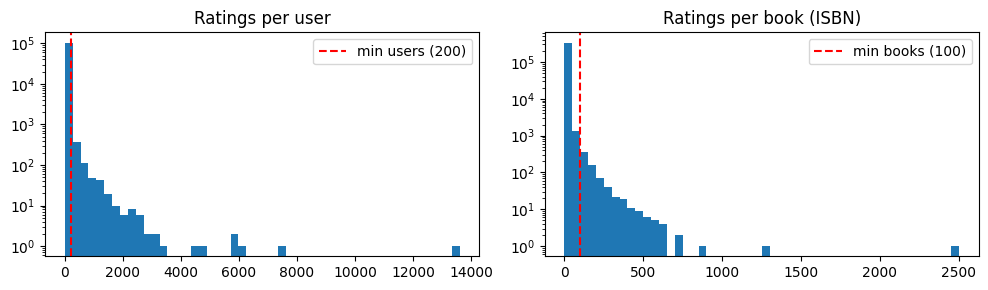

In [6]:
# add your code here - consider creating a new cell for each section of code

# ---------------------------------------------------------------------------
# 1) Statistical filters (FCC requirement)
#    Keep users with >= 200 ratings and books with >= 100 ratings so the
#    user–item matrix is dense enough for meaningful cosine KNN.
# ---------------------------------------------------------------------------
user_counts = df_ratings["user"].value_counts()
isbn_counts = df_ratings["isbn"].value_counts()

df_ratings_filtered = df_ratings[
    df_ratings["user"].isin(user_counts[user_counts >= 200].index)
    & df_ratings["isbn"].isin(isbn_counts[isbn_counts >= 100].index)
].copy()

print(
    f"ratings after filter: {len(df_ratings_filtered):,} "
    f"(from {len(df_ratings):,})"
)

# Attach titles (needed for lookup by book name)
df = df_ratings_filtered.merge(df_books, on="isbn", how="inner")
print(f"rows with titles: {len(df):,}; unique titles: {df['title'].nunique()}")

# ---------------------------------------------------------------------------
# 2) Book × user rating matrix
#    Rows = books, columns = users, values = rating (0 if missing).
#    Mean-aggregate rare duplicate (title, user) pairs from multi-ISBN titles.
# ---------------------------------------------------------------------------
book_user = (
    df.pivot_table(index="title", columns="user", values="rating", aggfunc="mean")
    .fillna(0)
)
print("matrix shape (books × users):", book_user.shape)

book_sparse = csr_matrix(book_user.values)

# ---------------------------------------------------------------------------
# 3) Cosine Nearest Neighbors on book vectors
# ---------------------------------------------------------------------------
knn = NearestNeighbors(metric="cosine", algorithm="brute")
knn.fit(book_sparse)

# Optional: rating-count distribution (helps show why filtering matters)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(user_counts.values, bins=50, log=True)
axes[0].axvline(200, color="r", linestyle="--", label="min users (200)")
axes[0].set_title("Ratings per user")
axes[0].legend()
axes[1].hist(isbn_counts.values, bins=50, log=True)
axes[1].axvline(100, color="r", linestyle="--", label="min books (100)")
axes[1].set_title("Ratings per book (ISBN)")
axes[1].legend()
plt.tight_layout()
plt.show()


In [8]:
# function to return recommended books - this will be tested
def get_recommends(book=""):
    """
    Return [query_title, [[rec_title, distance], ... x5]].

    Distances are cosine distances (0 = identical, 1 = orthogonal).
    The five neighbors are ordered farthest → closest among the top-5
    (matches the FreeCodeCamp sample / grader expectation).
    """
    if book not in book_user.index:
        raise KeyError(f"Book not found after filtering: {book!r}")

    # Row vector for this book in the sparse matrix
    idx = book_user.index.get_loc(book)
    distances, indices = knn.kneighbors(book_sparse[idx], n_neighbors=6)

    # index 0 is the book itself (distance ~0); take the next 5, reverse order
    neighbors = []
    for dist, neighbor_idx in zip(distances[0][1:], indices[0][1:]):
        neighbors.append([book_user.index[neighbor_idx], float(dist)])
    neighbors = neighbors[::-1]

    recommended_books = [book, neighbors]
    return recommended_books


In [9]:
books = get_recommends("Where the Heart Is (Oprah's Book Club (Paperback))")
print(books)

def test_book_recommendation():
  test_pass = True
  recommends = get_recommends("Where the Heart Is (Oprah's Book Club (Paperback))")
  if recommends[0] != "Where the Heart Is (Oprah's Book Club (Paperback))":
    test_pass = False
  recommended_books = ["I'll Be Seeing You", 'The Weight of Water', 'The Surgeon', 'I Know This Much Is True']
  recommended_books_dist = [0.8, 0.77, 0.77, 0.77]
  for i in range(2):
    if recommends[1][i][0] not in recommended_books:
      test_pass = False
    if abs(recommends[1][i][1] - recommended_books_dist[i]) >= 0.05:
      test_pass = False
  if test_pass:
    print("You passed the challenge! 🎉🎉🎉🎉🎉")
  else:
    print("You haven't passed yet. Keep trying!")

test_book_recommendation()

["Where the Heart Is (Oprah's Book Club (Paperback))", [["I'll Be Seeing You", 0.8016210794448853], ['The Weight of Water', 0.7708583474159241], ['The Surgeon', 0.7699410915374756], ['I Know This Much Is True', 0.7677075266838074], ['The Lovely Bones: A Novel', 0.7234864234924316]]]
You passed the challenge! 🎉🎉🎉🎉🎉
